In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(scutilsR)
library(tidyverse)
library(celda)
library(sceasy)
library(Nebulosa)
library(glue)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.2
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()

In [3]:
seu = qs::qread("/home/data/tanglei/project/prostate_altas/output/04/QC_fin.qs")

In [ ]:
seu_raw = qs::qread("/home/data/tanglei/project/prostate_altas/output/02/Integration_GSE.qs")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



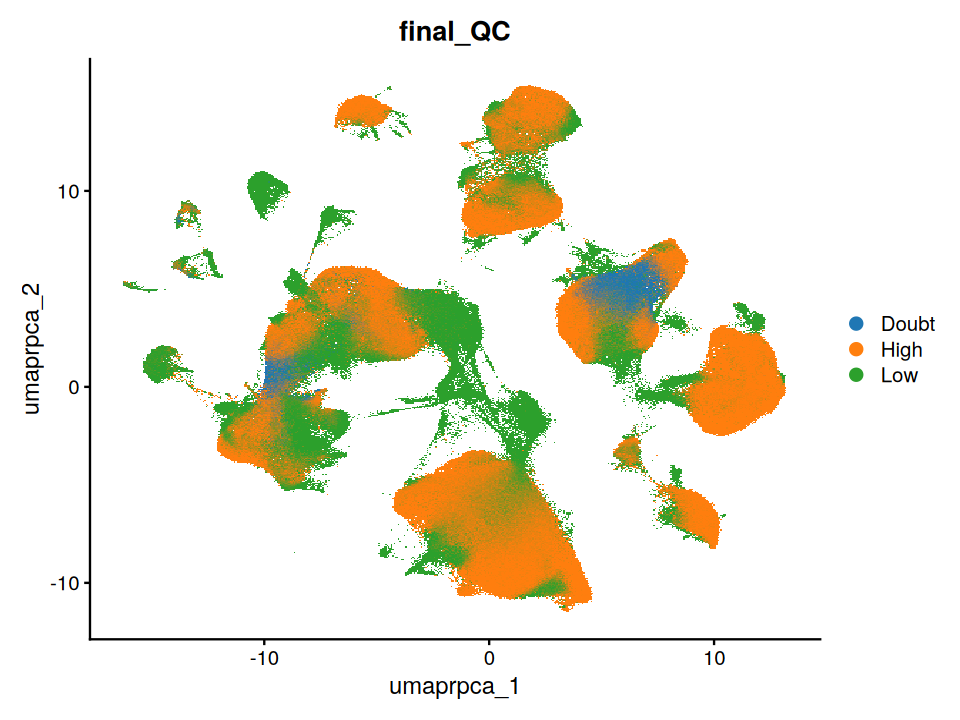

In [18]:
index = colnames(seu)
seu_raw$final_QC = ifelse(colnames(seu_raw) %in% index, "High", "Low")

Doubt = c("C1QA+IL10+ macrophage-like transitional monocyte","CLEC10A+HLA-DQA2+ dendritic cell-like transitional monocyte","KRT13+C19orf33+ hillock-like transitional basal cell","MMP7+PIGR+ club-like transitional luminal cell","APOC1+PLA2G7+ lipid-associated macrophage","IL1B+CXCL3+ M1-like inflammatory macrophage","TOP2A+CDK1+ cycling neuroendocrine cell")
index = rownames(filter(seu@meta.data,celltype_manual_H3 %in% Doubt))
seu_raw@meta.data[index,]$final_QC = "Doubt"

options(repr.plot.width = 8, repr.plot.height = 6)
DimPlot(
  seu_raw,
  reduction = "umap.rpca",
  group.by = "final_QC"
) + ggsci::scale_color_d3("category20", na.value = "grey80")



In [ ]:
## Sankey: GSE.ID -> final_QC
library(dplyr)
library(networkD3)
library(htmlwidgets)
library(htmltools)

Sys.setenv(OPENSSL_CONF = "/dev/null")

cellmeta <- seu_raw@meta.data

data.sankey <- cellmeta %>%
  filter(!is.na(GSE.ID), !is.na(final_QC)) %>%
  group_by(GSE.ID, final_QC) %>%
  summarise(value = n(), .groups = "drop") %>%
  transmute(
    source = paste0("L0_", GSE.ID),
    target = paste0("L1_QC_", final_QC),
    value
  )

links <- as.data.frame(data.sankey, stringsAsFactors = FALSE)

nodes <- data.frame(
  name = unique(c(links$source, links$target)),
  stringsAsFactors = FALSE
)

links$IDsource <- match(links$source, nodes$name) - 1
links$IDtarget <- match(links$target, nodes$name) - 1

plot.h <- 1000
plot.w <- 800

g <- sankeyNetwork(
  Links = links,
  Nodes = nodes,
  Source = "IDsource",
  Target = "IDtarget",
  Value = "value",
  NodeID = "name",
  sinksRight = FALSE,
  fontSize = 13,
  nodeWidth = 12,
  nodePadding = 10,
  margin = list(left = 10, right = 120, top = 10, bottom = 10),
  height = plot.h,
  width = plot.w
)

g <- htmlwidgets::onRender(g, '
  function(el, x) {
    var nodeColorMap = {};

    d3.select(el).selectAll(".node").each(function(d) {
      nodeColorMap[d.name] =
        d3.select(this).select("rect").style("fill");
    });

    d3.select(el).selectAll(".link")
      .style("stroke", function(d) {
        return nodeColorMap[d.source.name] || "#888";
      })
      .style("stroke-opacity", 0.25);

    d3.select(el).selectAll(".node text")
      .text(function(d) {
        return d.name.replace(/^L[0-9]+_/, "");
      })
      .style("font-weight", "bold");
  }
')

g <- htmlwidgets::prependContent(
  g,
  htmltools::tags$h3(
    "GSE → final_QC",
    style = paste0(
      "text-align:left;",
      "font-family:sans-serif;",
      "margin-bottom:0;",
      "padding-left:30px;"
    )
  )
)

g

output_dir <- "/home/data/tanglei/project/prostate_altas/output/04"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

html.out <- file.path(output_dir, "sankey_gse_final_QC.html")
pdf.out  <- file.path(output_dir, "sankey_gse_final_QC.pdf")

saveWidget(g, file = html.out, selfcontained = FALSE)

webshot::webshot(
  url = html.out,
  file = pdf.out,
  vwidth = plot.w + 60,
  vheight = plot.h + 80,
  delay = 2
)

In [25]:
Doubt = c("C1QA+IL10+ macrophage-like transitional monocyte","CLEC10A+HLA-DQA2+ dendritic cell-like transitional monocyte","KRT13+C19orf33+ hillock-like transitional basal cell","MMP7+PIGR+ club-like transitional luminal cell","APOC1+PLA2G7+ lipid-associated macrophage","IL1B+CXCL3+ M1-like inflammatory macrophage","TOP2A+CDK1+ cycling neuroendocrine cell")
seu$QC_fin = ifelse(seu$celltype_manual_H3 %in% Doubt, "Doubt", "High")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



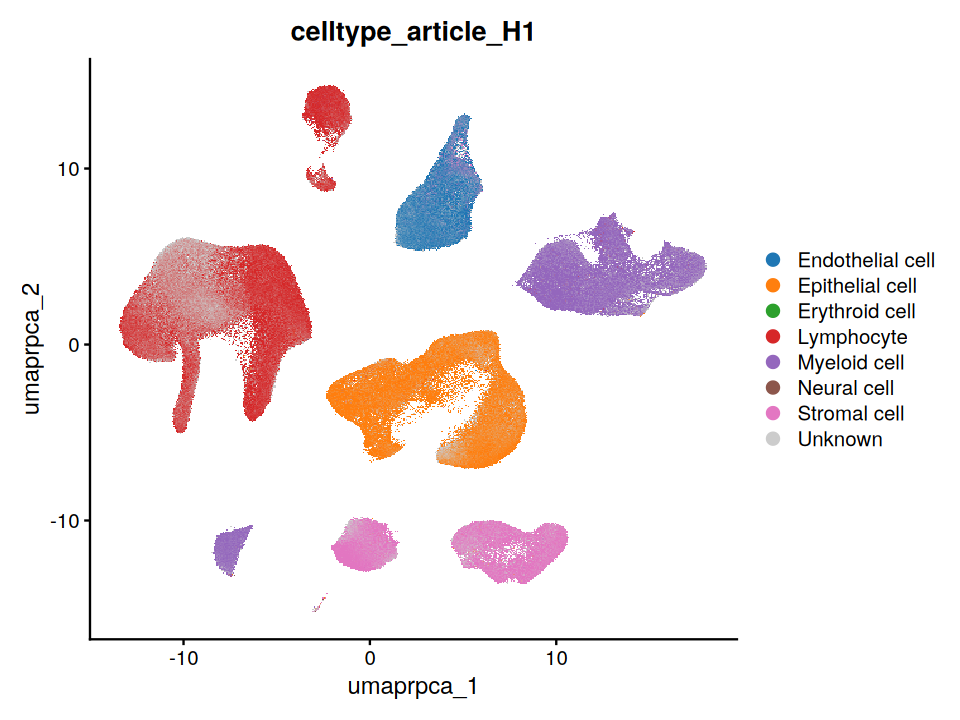

In [10]:
library(Seurat)
library(ggplot2)
library(ggsci)
library(scales)

group_var <- "celltype_article_H1"

# NA -> Unknown
seu[[group_var]][, 1] <- as.character(seu[[group_var]][, 1])
seu[[group_var]][is.na(seu[[group_var]][, 1]), 1] <- "Unknown"

# 全部类别
all_types <- sort(unique(seu[[group_var]][, 1]))
types_non_unknown <- setdiff(all_types, "Unknown")
n_non_unknown <- length(types_non_unknown)

# 智能配色
if (n_non_unknown <= 20) {
  # 直接用 category20，不做扩展
  base20 <- ggsci::pal_d3("category20")(20)
  cols_non_unknown <- setNames(base20[seq_len(n_non_unknown)], types_non_unknown)
} else {
  # 类别太多时再扩展
  igv_base <- ggsci::pal_igv("default")(51)
  cols_non_unknown <- setNames(
    colorRampPalette(igv_base)(n_non_unknown),
    types_non_unknown
  )
}

# Unknown 固定灰色
custom_cols <- c(cols_non_unknown, Unknown = "grey80")

DimPlot(
  seu,
  group.by = group_var,
  reduction = "umap.rpca",
  label = FALSE
) +
  scale_color_manual(values = custom_cols, drop = FALSE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



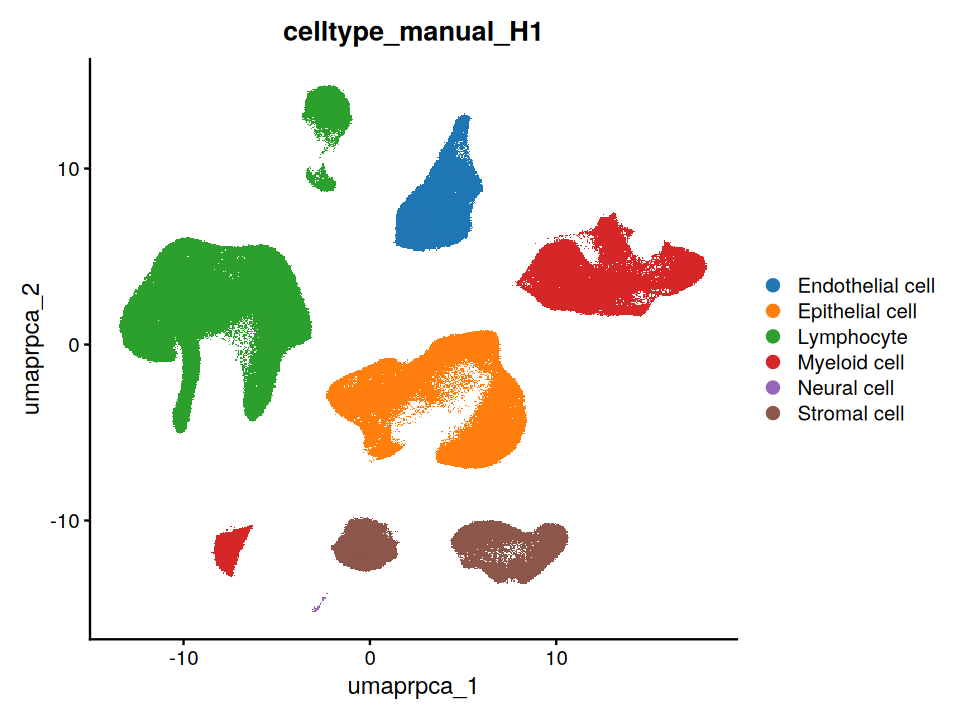

In [14]:
DimPlot(
  seu,
  group.by = "celltype_manual_H1",
  reduction = "umap.rpca",
  label = FALSE
) + ggsci::scale_color_d3("category20", na.value = "grey80")


In [ ]:
## Sankey: celltype_article_H1 -> celltype_manual_H1
library(dplyr)
library(networkD3)
library(htmlwidgets)
library(htmltools)

Sys.setenv(OPENSSL_CONF = "/dev/null")

cellmeta <- seu@meta.data

## NA 统一改成 Unknown，避免整行被丢掉
cellmeta.sankey <- cellmeta %>%
  mutate(
    celltype_article_H1 = ifelse(is.na(celltype_article_H1), "Unknown", as.character(celltype_article_H1)),
    celltype_manual_H1  = ifelse(is.na(celltype_manual_H1),  "Unknown", as.character(celltype_manual_H1))
  )

data.sankey <- cellmeta.sankey %>%
  group_by(celltype_article_H1, celltype_manual_H1) %>%
  summarise(value = n(), .groups = "drop") %>%
  transmute(
    source = paste0("L0_article_", celltype_article_H1),
    target = paste0("L1_manual_",  celltype_manual_H1),
    value
  )

links <- as.data.frame(data.sankey, stringsAsFactors = FALSE)

nodes <- data.frame(
  name = unique(c(links$source, links$target)),
  stringsAsFactors = FALSE
)

links$IDsource <- match(links$source, nodes$name) - 1
links$IDtarget <- match(links$target, nodes$name) - 1

## 高度按单侧最大节点数撑开，细胞类型名较长所以宽度给足
n.side <- max(
  n_distinct(cellmeta.sankey$celltype_article_H1),
  n_distinct(cellmeta.sankey$celltype_manual_H1)
)
plot.h <- max(700, n.side * 28)
plot.w <- 1000

g <- sankeyNetwork(
  Links = links,
  Nodes = nodes,
  Source = "IDsource",
  Target = "IDtarget",
  Value = "value",
  NodeID = "name",
  sinksRight = FALSE,
  fontSize = 13,
  nodeWidth = 12,
  nodePadding = 12,
  margin = list(left = 10, right = 260, top = 10, bottom = 10),
  height = plot.h,
  width = plot.w
)

g <- htmlwidgets::onRender(g, '
  function(el, x) {
    var nodeColorMap = {};

    d3.select(el).selectAll(".node").each(function(d) {
      nodeColorMap[d.name] =
        d3.select(this).select("rect").style("fill");
    });

    d3.select(el).selectAll(".link")
      .style("stroke", function(d) {
        return nodeColorMap[d.source.name] || "#888";
      })
      .style("stroke-opacity", 0.25);

    d3.select(el).selectAll(".node text")
      .text(function(d) {
        return d.name.replace(/^L[0-9]+_/, "");
      })
      .style("font-weight", "bold");
  }
')

g <- htmlwidgets::prependContent(
  g,
  htmltools::tags$h3(
    "celltype_article_H1 → celltype_manual_H1",
    style = paste0(
      "text-align:left;",
      "font-family:sans-serif;",
      "margin-bottom:0;",
      "padding-left:30px;"
    )
  )
)

g

output_dir <- "/home/data/tanglei/project/prostate_altas/output/04"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

html.out <- file.path(output_dir, "sankey_article_H1_to_manual_H1.html")
pdf.out  <- file.path(output_dir, "sankey_article_H1_to_manual_H1.pdf")

saveWidget(g, file = html.out, selfcontained = FALSE)

webshot::webshot(
  url = html.out,
  file = pdf.out,
  vwidth = plot.w + 60,
  vheight = plot.h + 80,
  delay = 2
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



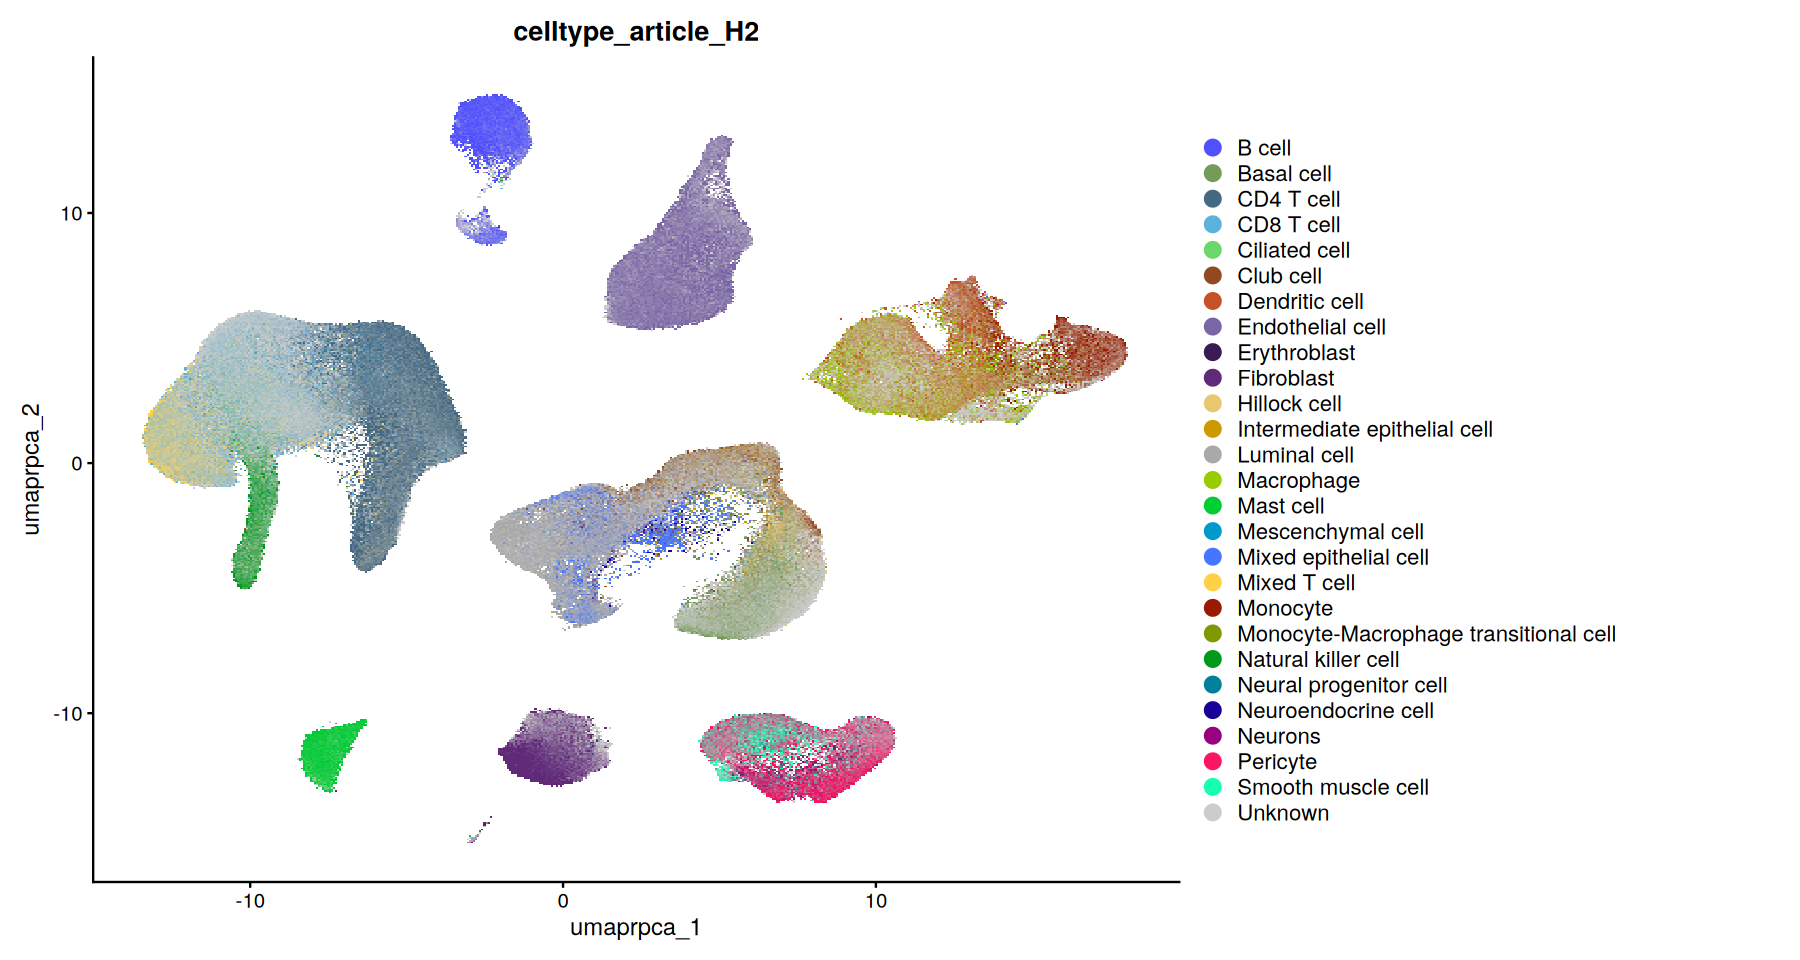

In [39]:
library(Seurat)
library(ggplot2)
library(ggsci)
library(scales)
library(cowplot)

group_var <- "celltype_article_H2"

# NA -> Unknown
seu[[group_var]][, 1] <- as.character(seu[[group_var]][, 1])
seu[[group_var]][is.na(seu[[group_var]][, 1]), 1] <- "Unknown"

# 全部类别
all_types <- sort(unique(seu[[group_var]][, 1]))
types_non_unknown <- setdiff(all_types, "Unknown")
n_non_unknown <- length(types_non_unknown)
n_all <- length(all_types)

# 智能配色
if (n_non_unknown <= 20) {
  base20 <- ggsci::pal_d3("category20")(20)
  cols_non_unknown <- setNames(base20[seq_len(n_non_unknown)], types_non_unknown)
} else {
  igv_base <- ggsci::pal_igv("default")(51)
  cols_non_unknown <- setNames(
    colorRampPalette(igv_base)(n_non_unknown),
    types_non_unknown
  )
}

custom_cols <- c(cols_non_unknown, Unknown = "grey80")

legend_ncol <- if (n_all <= 30) 1 else 2

# 主图：DimPlot 默认样式，不要 legend 和 label
p_main <- DimPlot(
  seu,
  group.by = group_var,
  reduction = "umap.rpca"
) +
  scale_color_manual(values = custom_cols, drop = FALSE) +
  NoLegend()

# 只用来生成 legend 的图，字号放大
p_legend <- cowplot::get_legend(
  DimPlot(
    seu,
    group.by = group_var,
    reduction = "umap.rpca"
  ) +
    scale_color_manual(values = custom_cols, drop = FALSE) +
    theme(
      legend.title = element_blank(),
      legend.text  = element_text(size = 13)
    ) +
    guides(color = guide_legend(ncol = legend_ncol, override.aes = list(size = 4)))
)

# legend 侧加宽，避免长标签被裁切（cell 末尾的 l 等）
p <- cowplot::plot_grid(
  p_main, p_legend,
  ncol = 2,
  rel_widths = c(1, 0.5 * legend_ncol),
  align = "h",
  axis = "tb"
)

options(
  repr.plot.width  = 8 + 7 * legend_ncol,
  repr.plot.height = 8
)

p

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



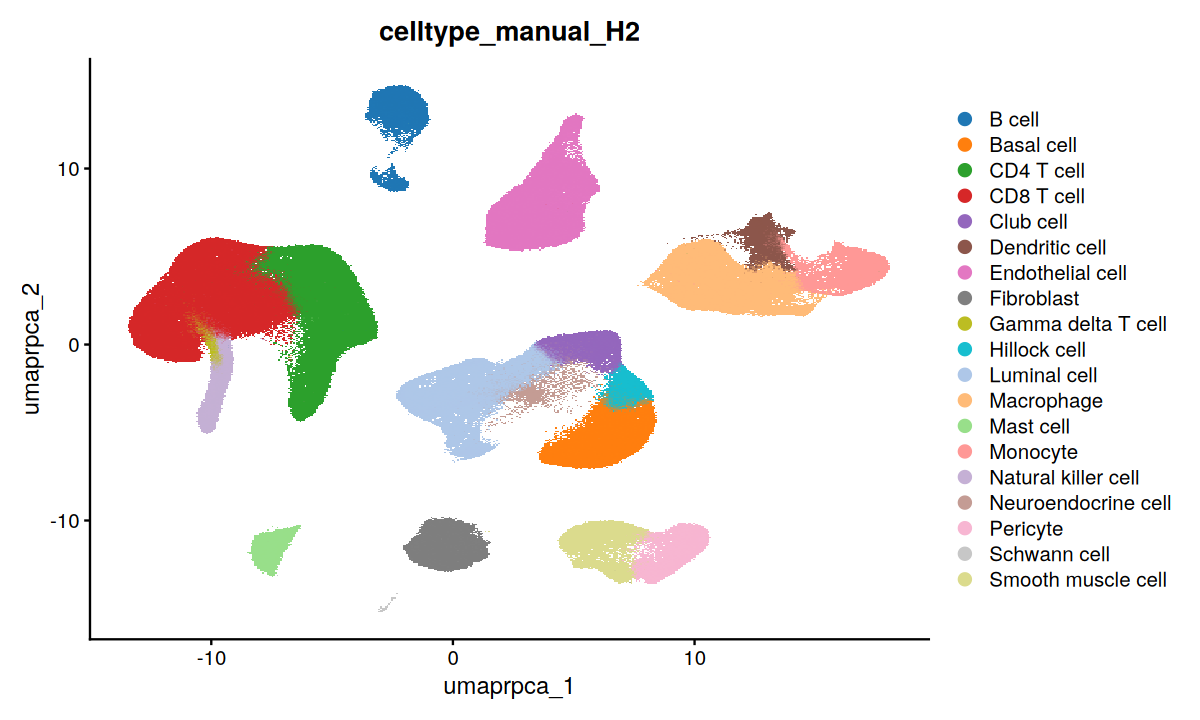

In [90]:
options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(
  seu,
  group.by = "celltype_manual_H2",
  reduction = "umap.rpca",
  label = FALSE
) + ggsci::scale_color_d3("category20", na.value = "grey80")


In [ ]:
## Sankey: celltype_article_H2 -> celltype_manual_H2
library(dplyr)
library(networkD3)
library(htmlwidgets)
library(htmltools)

Sys.setenv(OPENSSL_CONF = "/dev/null")

cellmeta <- seu@meta.data

## NA 统一改成 Unknown，避免整行被丢掉
cellmeta.sankey <- cellmeta %>%
  mutate(
    celltype_article_H2 = ifelse(is.na(celltype_article_H2), "Unknown", as.character(celltype_article_H2)),
    celltype_manual_H2  = ifelse(is.na(celltype_manual_H2),  "Unknown", as.character(celltype_manual_H2))
  )

data.sankey <- cellmeta.sankey %>%
  group_by(celltype_article_H2, celltype_manual_H2) %>%
  summarise(value = n(), .groups = "drop") %>%
  transmute(
    source = paste0("L0_article_", celltype_article_H2),
    target = paste0("L1_manual_",  celltype_manual_H2),
    value
  )

links <- as.data.frame(data.sankey, stringsAsFactors = FALSE)

nodes <- data.frame(
  name = unique(c(links$source, links$target)),
  stringsAsFactors = FALSE
)

links$IDsource <- match(links$source, nodes$name) - 1
links$IDtarget <- match(links$target, nodes$name) - 1

## 高度按单侧最大节点数撑开，细胞类型名较长所以宽度给足
n.side <- max(
  n_distinct(cellmeta.sankey$celltype_article_H2),
  n_distinct(cellmeta.sankey$celltype_manual_H2)
)
plot.h <- max(700, n.side * 28)
plot.w <- 1000

g <- sankeyNetwork(
  Links = links,
  Nodes = nodes,
  Source = "IDsource",
  Target = "IDtarget",
  Value = "value",
  NodeID = "name",
  sinksRight = FALSE,
  fontSize = 13,
  nodeWidth = 12,
  nodePadding = 12,
  margin = list(left = 10, right = 260, top = 10, bottom = 10),
  height = plot.h,
  width = plot.w
)

g <- htmlwidgets::onRender(g, '
  function(el, x) {
    var nodeColorMap = {};

    d3.select(el).selectAll(".node").each(function(d) {
      nodeColorMap[d.name] =
        d3.select(this).select("rect").style("fill");
    });

    d3.select(el).selectAll(".link")
      .style("stroke", function(d) {
        return nodeColorMap[d.source.name] || "#888";
      })
      .style("stroke-opacity", 0.25);

    d3.select(el).selectAll(".node text")
      .text(function(d) {
        return d.name.replace(/^L[0-9]+_/, "");
      })
      .style("font-weight", "bold");
  }
')

g <- htmlwidgets::prependContent(
  g,
  htmltools::tags$h3(
    "celltype_article_H2 → celltype_manual_H2",
    style = paste0(
      "text-align:left;",
      "font-family:sans-serif;",
      "margin-bottom:0;",
      "padding-left:30px;"
    )
  )
)

g

output_dir <- "/home/data/tanglei/project/prostate_altas/output/04"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

html.out <- file.path(output_dir, "sankey_article_H2_to_manual_H2.html")
pdf.out  <- file.path(output_dir, "sankey_article_H2_to_manual_H2.pdf")

saveWidget(g, file = html.out, selfcontained = FALSE)

webshot::webshot(
  url = html.out,
  file = pdf.out,
  vwidth = plot.w + 60,
  vheight = plot.h + 80,
  delay = 2
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



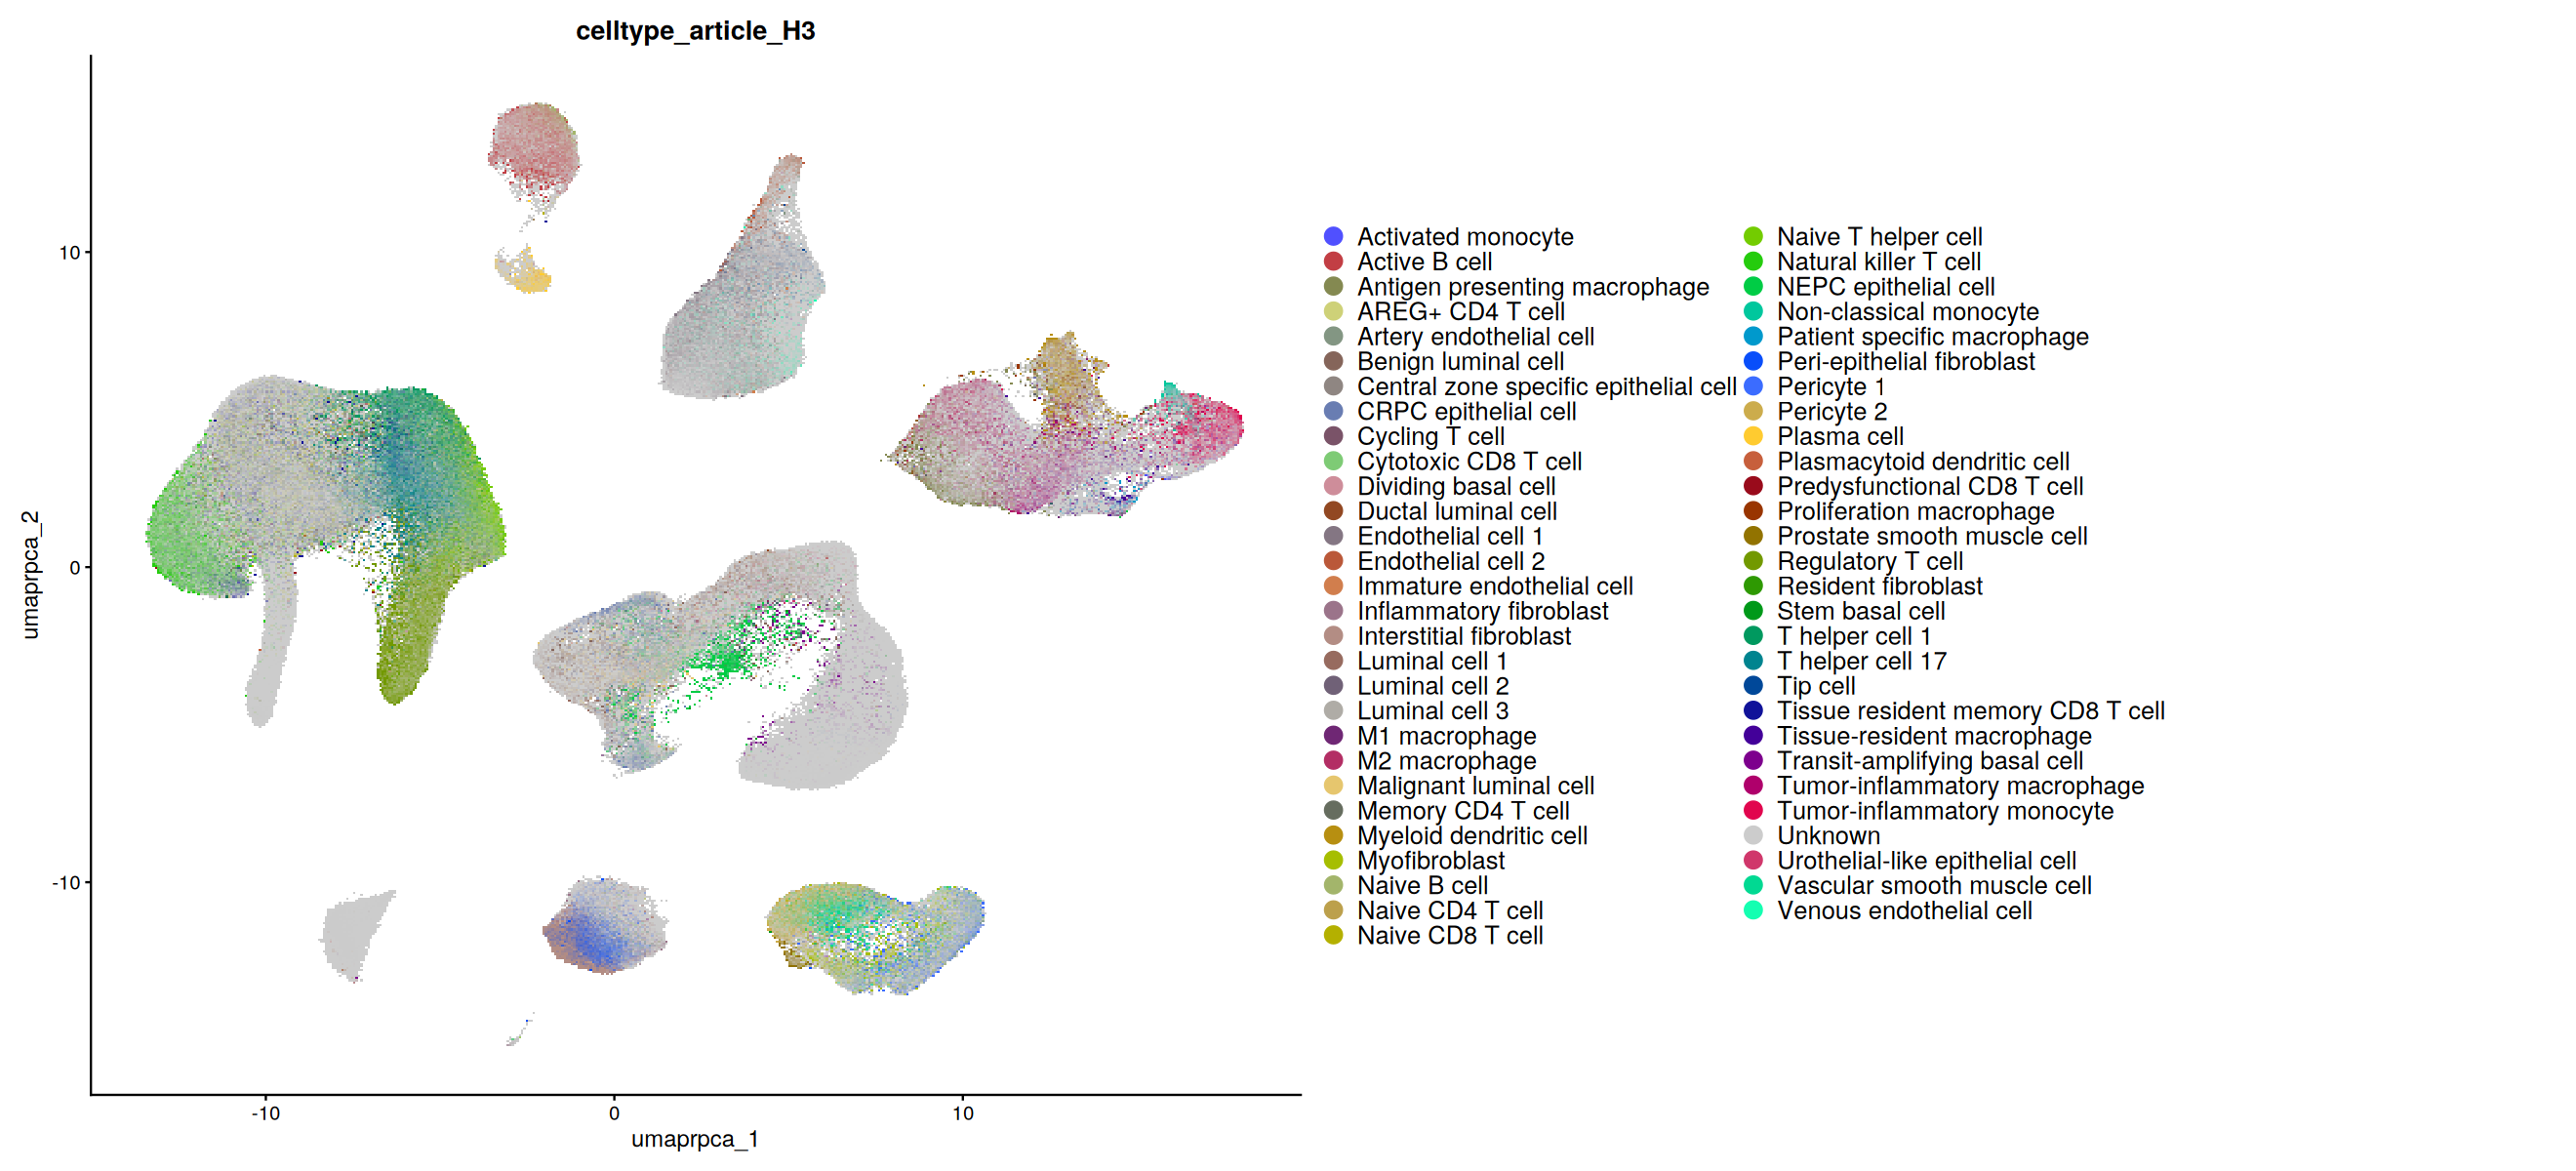

In [54]:
library(Seurat)
library(ggplot2)
library(ggsci)
library(scales)
library(cowplot)

group_var <- "celltype_article_H3"

# NA -> Unknown
seu[[group_var]][, 1] <- as.character(seu[[group_var]][, 1])
seu[[group_var]][is.na(seu[[group_var]][, 1]), 1] <- "Unknown"

# 全部类别
all_types <- sort(unique(seu[[group_var]][, 1]))
types_non_unknown <- setdiff(all_types, "Unknown")
n_non_unknown <- length(types_non_unknown)
n_all <- length(all_types)

# 智能配色
if (n_non_unknown <= 20) {
  base20 <- ggsci::pal_d3("category20")(20)
  cols_non_unknown <- setNames(base20[seq_len(n_non_unknown)], types_non_unknown)
} else {
  igv_base <- ggsci::pal_igv("default")(51)
  cols_non_unknown <- setNames(
    colorRampPalette(igv_base)(n_non_unknown),
    types_non_unknown
  )
}

custom_cols <- c(cols_non_unknown, Unknown = "grey80")

# 尽量一列，不行再两列
legend_ncol <- if (n_all <= 30) 1 else 2

# 两列时字号略加大，补偿显示缩放
legend_text_size <- if (legend_ncol == 1) 13 else 15
legend_pt_size   <- if (legend_ncol == 1) 4 else 4.5

# 主图：DimPlot 默认样式，不要 legend 和 label
p_main <- DimPlot(
  seu,
  group.by = group_var,
  reduction = "umap.rpca"
) +
  scale_color_manual(values = custom_cols, drop = FALSE) +
  NoLegend()

# 只用来生成 legend
p_legend <- cowplot::get_legend(
  DimPlot(
    seu,
    group.by = group_var,
    reduction = "umap.rpca"
  ) +
    scale_color_manual(values = custom_cols, drop = FALSE) +
    theme(
      legend.title = element_blank(),
      legend.text  = element_text(size = legend_text_size)
    ) +
    guides(color = guide_legend(ncol = legend_ncol, override.aes = list(size = legend_pt_size)))
)

# 主图宽度份额固定；两列只略增 legend 侧，避免整图画布过宽被 Jupyter 缩小
rel_w <- if (legend_ncol == 1) c(1, 0.55) else c(1, 0.95)

p <- cowplot::plot_grid(
  p_main, p_legend,
  ncol = 2,
  rel_widths = rel_w,
  align = "h",
  axis = "tb"
)

# 两列：主要加高，宽度别涨太多
options(
  repr.plot.width  = if (legend_ncol == 1) 12 else 22,
  repr.plot.height = 10
)

p

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



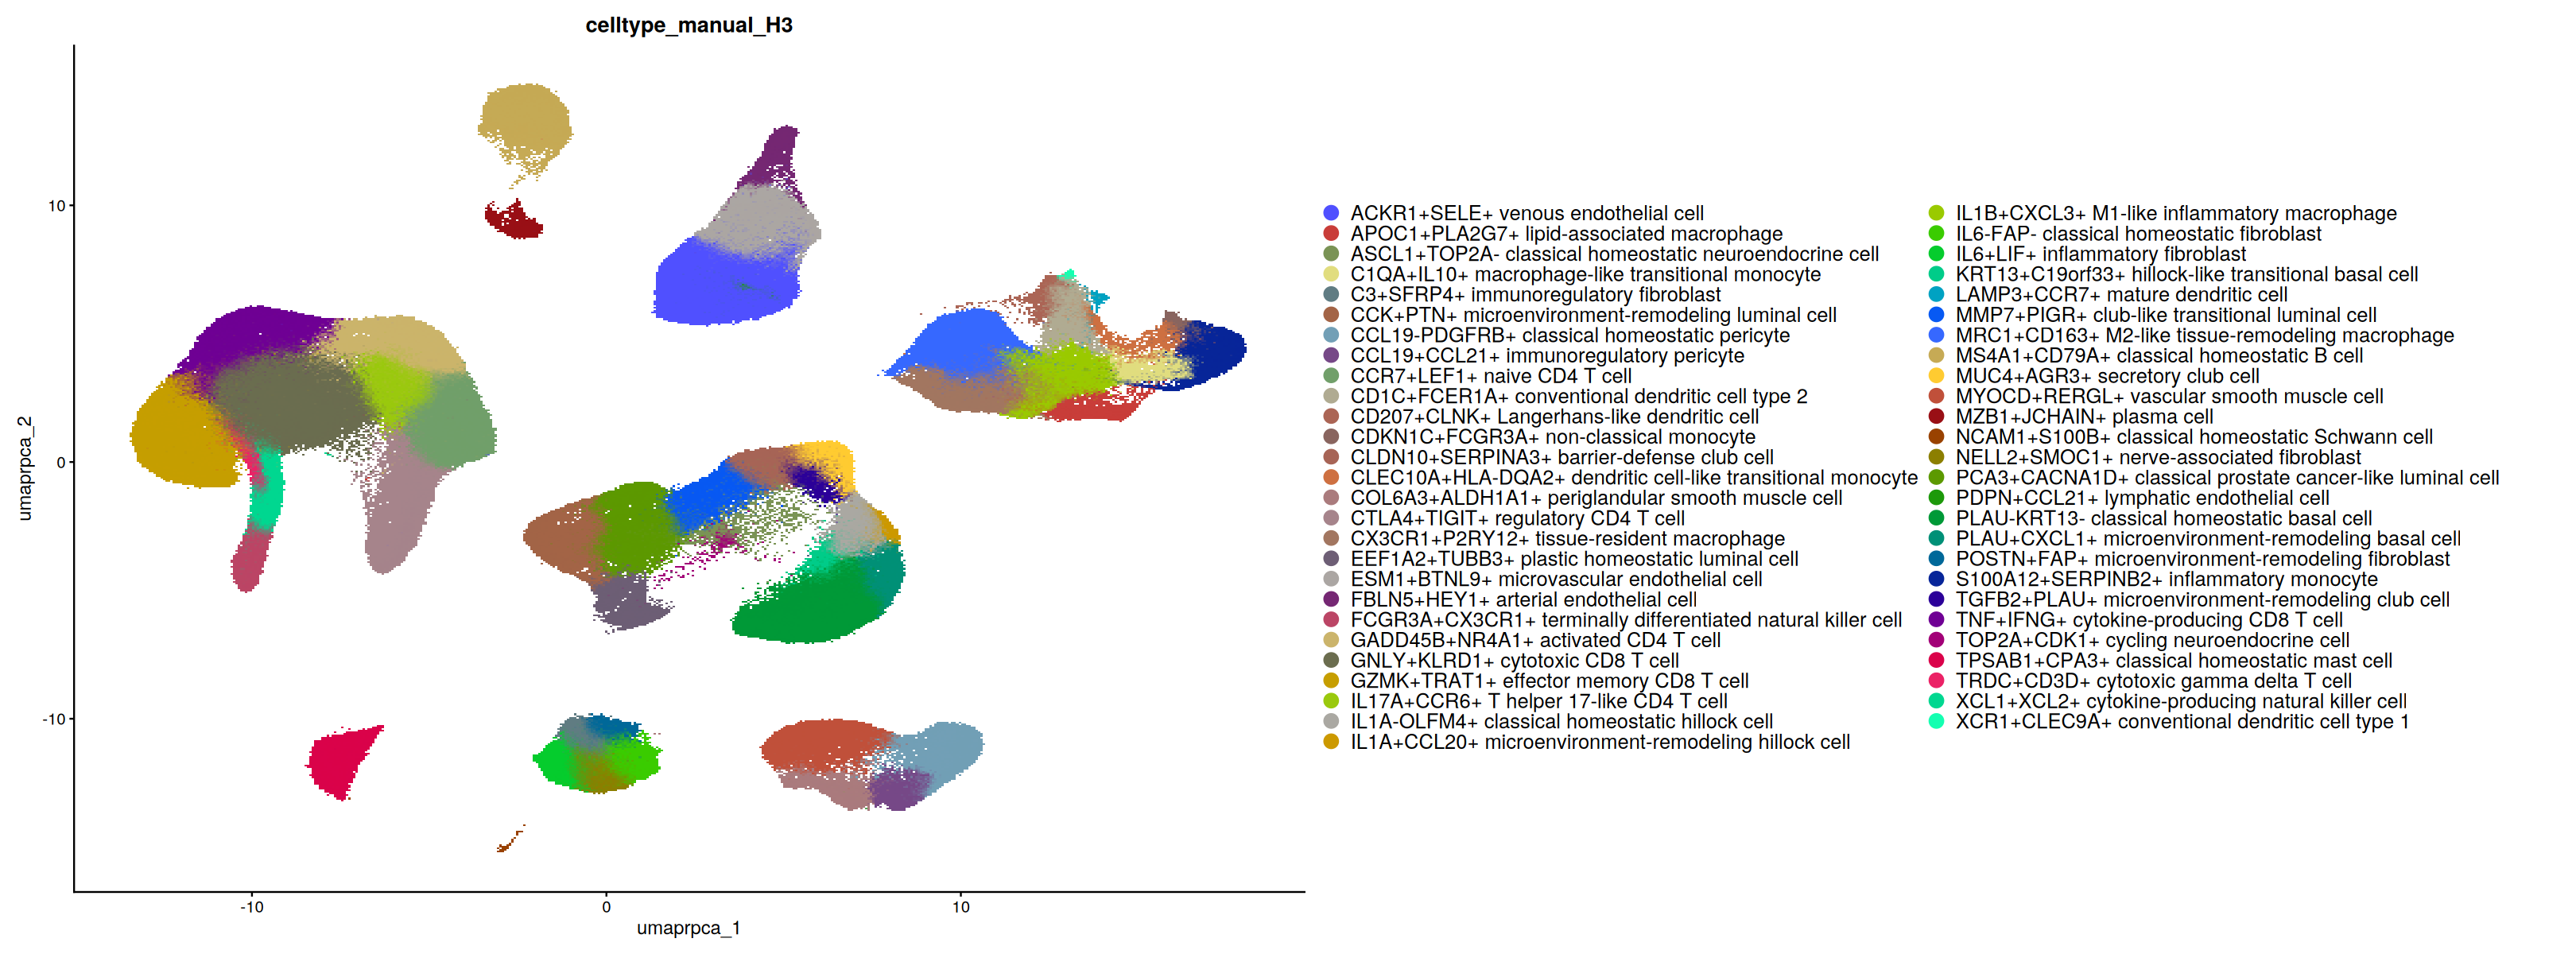

In [5]:
library(Seurat)
library(ggplot2)
library(ggsci)
library(scales)
library(cowplot)

group_var <- "celltype_manual_H3"

# NA -> Unknown
seu[[group_var]][, 1] <- as.character(seu[[group_var]][, 1])
seu[[group_var]][is.na(seu[[group_var]][, 1]), 1] <- "Unknown"

# 全部类别
all_types <- sort(unique(seu[[group_var]][, 1]))
types_non_unknown <- setdiff(all_types, "Unknown")
n_non_unknown <- length(types_non_unknown)
n_all <- length(all_types)

# 智能配色
if (n_non_unknown <= 20) {
  base20 <- ggsci::pal_d3("category20")(20)
  cols_non_unknown <- setNames(base20[seq_len(n_non_unknown)], types_non_unknown)
} else {
  igv_base <- ggsci::pal_igv("default")(51)
  cols_non_unknown <- setNames(
    colorRampPalette(igv_base)(n_non_unknown),
    types_non_unknown
  )
}

custom_cols <- c(cols_non_unknown, Unknown = "grey80")

# 尽量一列，不行再两列
legend_ncol <- if (n_all <= 30) 1 else 2

# 两列时字号略加大，补偿显示缩放
legend_text_size <- if (legend_ncol == 1) 13 else 15
legend_pt_size   <- if (legend_ncol == 1) 4 else 4.5

# 主图：DimPlot 默认样式，不要 legend 和 label
p_main <- DimPlot(
  seu,
  group.by = group_var,
  reduction = "umap.rpca"
) +
  scale_color_manual(values = custom_cols, drop = FALSE) +
  NoLegend()

# 只用来生成 legend
p_legend <- cowplot::get_legend(
  DimPlot(
    seu,
    group.by = group_var,
    reduction = "umap.rpca"
  ) +
    scale_color_manual(values = custom_cols, drop = FALSE) +
    theme(
      legend.title = element_blank(),
      legend.text  = element_text(size = legend_text_size)
    ) +
    guides(color = guide_legend(ncol = legend_ncol, override.aes = list(size = legend_pt_size)))
)

# 主图宽度份额固定；两列只略增 legend 侧，避免整图画布过宽被 Jupyter 缩小
rel_w <- if (legend_ncol == 1) c(1, 0.55) else c(1, 0.95)

p <- cowplot::plot_grid(
  p_main, p_legend,
  ncol = 2,
  rel_widths = rel_w,
  align = "h",
  axis = "tb"
)

# 两列：主要加高，宽度别涨太多
options(
  repr.plot.width  = if (legend_ncol == 1) 12 else 27,
  repr.plot.height = 10
)

p

In [ ]:
## Sankey: celltype_article_H3 -> celltype_manual_H3
library(dplyr)
library(networkD3)
library(htmlwidgets)
library(htmltools)

Sys.setenv(OPENSSL_CONF = "/dev/null")

cellmeta <- seu@meta.data

## NA 统一改成 Unknown，避免整行被丢掉
cellmeta.sankey <- cellmeta %>%
  mutate(
    celltype_article_H3 = ifelse(is.na(celltype_article_H3), "Unknown", as.character(celltype_article_H3)),
    celltype_manual_H3  = ifelse(is.na(celltype_manual_H3),  "Unknown", as.character(celltype_manual_H3))
  )

data.sankey <- cellmeta.sankey %>%
  group_by(celltype_article_H3, celltype_manual_H3) %>%
  summarise(value = n(), .groups = "drop") %>%
  transmute(
    source = paste0("L0_article_", celltype_article_H3),
    target = paste0("L1_manual_",  celltype_manual_H3),
    value
  )

links <- as.data.frame(data.sankey, stringsAsFactors = FALSE)

nodes <- data.frame(
  name = unique(c(links$source, links$target)),
  stringsAsFactors = FALSE
)

links$IDsource <- match(links$source, nodes$name) - 1
links$IDtarget <- match(links$target, nodes$name) - 1

## 高度按单侧最大节点数撑开，细胞类型名较长所以宽度给足
n.side <- max(
  n_distinct(cellmeta.sankey$celltype_article_H3),
  n_distinct(cellmeta.sankey$celltype_manual_H3)
)
plot.h <- max(700, n.side * 28)
plot.w <- 1000

g <- sankeyNetwork(
  Links = links,
  Nodes = nodes,
  Source = "IDsource",
  Target = "IDtarget",
  Value = "value",
  NodeID = "name",
  sinksRight = FALSE,
  fontSize = 13,
  nodeWidth = 12,
  nodePadding = 12,
  margin = list(left = 10, right = 260, top = 10, bottom = 10),
  height = plot.h,
  width = plot.w
)

g <- htmlwidgets::onRender(g, '
  function(el, x) {
    var nodeColorMap = {};

    d3.select(el).selectAll(".node").each(function(d) {
      nodeColorMap[d.name] =
        d3.select(this).select("rect").style("fill");
    });

    d3.select(el).selectAll(".link")
      .style("stroke", function(d) {
        return nodeColorMap[d.source.name] || "#888";
      })
      .style("stroke-opacity", 0.25);

    d3.select(el).selectAll(".node text")
      .text(function(d) {
        return d.name.replace(/^L[0-9]+_/, "");
      })
      .style("font-weight", "bold");
  }
')

g <- htmlwidgets::prependContent(
  g,
  htmltools::tags$h3(
    "celltype_article_H3 → celltype_manual_H3",
    style = paste0(
      "text-align:left;",
      "font-family:sans-serif;",
      "margin-bottom:0;",
      "padding-left:30px;"
    )
  )
)

g

output_dir <- "/home/data/tanglei/project/prostate_altas/output/04"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

html.out <- file.path(output_dir, "sankey_article_H3_to_manual_H3.html")
pdf.out  <- file.path(output_dir, "sankey_article_H3_to_manual_H3.pdf")

saveWidget(g, file = html.out, selfcontained = FALSE)

webshot::webshot(
  url = html.out,
  file = pdf.out,
  vwidth = plot.w + 60,
  vheight = plot.h + 80,
  delay = 2
)

In [ ]:
## =========================
## Sankey 1: article H1 -> H2 -> H3
## =========================
library(dplyr)
library(networkD3)
library(htmlwidgets)
library(htmltools)

Sys.setenv(OPENSSL_CONF = "/dev/null")

make_three_level_sankey <- function(meta, col1, col2, col3,
                                    title, html.out, pdf.out,
                                    prefix1 = "H1_", prefix2 = "H2_", prefix3 = "H3_") {
  cellmeta.sankey <- meta %>%
    transmute(
      l1 = ifelse(is.na(.data[[col1]]), "Unknown", as.character(.data[[col1]])),
      l2 = ifelse(is.na(.data[[col2]]), "Unknown", as.character(.data[[col2]])),
      l3 = ifelse(is.na(.data[[col3]]), "Unknown", as.character(.data[[col3]]))
    )

  links.12 <- cellmeta.sankey %>%
    group_by(l1, l2) %>%
    summarise(value = n(), .groups = "drop") %>%
    transmute(
      source = paste0("L0_", prefix1, l1),
      target = paste0("L1_", prefix2, l2),
      value
    )

  links.23 <- cellmeta.sankey %>%
    group_by(l2, l3) %>%
    summarise(value = n(), .groups = "drop") %>%
    transmute(
      source = paste0("L1_", prefix2, l2),
      target = paste0("L2_", prefix3, l3),
      value
    )

  links <- bind_rows(links.12, links.23) %>%
    as.data.frame(stringsAsFactors = FALSE)

  nodes <- data.frame(
    name = unique(c(links$source, links$target)),
    stringsAsFactors = FALSE
  )

  links$IDsource <- match(links$source, nodes$name) - 1
  links$IDtarget <- match(links$target, nodes$name) - 1

  n.side <- max(
    n_distinct(cellmeta.sankey$l1),
    n_distinct(cellmeta.sankey$l2),
    n_distinct(cellmeta.sankey$l3)
  )
  plot.h <- max(900, n.side * 22)
  plot.w <- 1200

  g <- sankeyNetwork(
    Links = links,
    Nodes = nodes,
    Source = "IDsource",
    Target = "IDtarget",
    Value = "value",
    NodeID = "name",
    sinksRight = FALSE,
    fontSize = 12,
    nodeWidth = 12,
    nodePadding = 10,
    margin = list(left = 10, right = 280, top = 10, bottom = 10),
    height = plot.h,
    width = plot.w
  )

  g <- htmlwidgets::onRender(g, '
    function(el, x) {
      var nodeColorMap = {};

      d3.select(el).selectAll(".node").each(function(d) {
        nodeColorMap[d.name] =
          d3.select(this).select("rect").style("fill");
      });

      d3.select(el).selectAll(".link")
        .style("stroke", function(d) {
          return nodeColorMap[d.source.name] || "#888";
        })
        .style("stroke-opacity", 0.25);

      d3.select(el).selectAll(".node text")
        .text(function(d) {
          return d.name.replace(/^L[0-9]+_/, "");
        })
        .style("font-weight", "bold");
    }
  ')

  g <- htmlwidgets::prependContent(
    g,
    htmltools::tags$h3(
      title,
      style = paste0(
        "text-align:left;",
        "font-family:sans-serif;",
        "margin-bottom:0;",
        "padding-left:30px;"
      )
    )
  )

  dir.create(dirname(html.out), recursive = TRUE, showWarnings = FALSE)
  saveWidget(g, file = html.out, selfcontained = FALSE)

  webshot::webshot(
    url = html.out,
    file = pdf.out,
    vwidth = plot.w + 60,
    vheight = plot.h + 80,
    delay = 2
  )

  g
}

output_dir <- "/home/data/tanglei/project/prostate_altas/output/04"

## 1) article H1 -> H2 -> H3
g_article <- make_three_level_sankey(
  meta = seu@meta.data,
  col1 = "celltype_article_H1",
  col2 = "celltype_article_H2",
  col3 = "celltype_article_H3",
  title = "article_H1 → article_H2 → article_H3",
  html.out = file.path(output_dir, "sankey_article_H1_H2_H3.html"),
  pdf.out  = file.path(output_dir, "sankey_article_H1_H2_H3.pdf"),
  prefix1 = "article_H1_",
  prefix2 = "article_H2_",
  prefix3 = "article_H3_"
)
g_article

## 2) manual H1 -> H2 -> H3
g_manual <- make_three_level_sankey(
  meta = seu@meta.data,
  col1 = "celltype_manual_H1",
  col2 = "celltype_manual_H2",
  col3 = "celltype_manual_H3",
  title = "manual_H1 → manual_H2 → manual_H3",
  html.out = file.path(output_dir, "sankey_manual_H1_H2_H3.html"),
  pdf.out  = file.path(output_dir, "sankey_manual_H1_H2_H3.pdf"),
  prefix1 = "manual_H1_",
  prefix2 = "manual_H2_",
  prefix3 = "manual_H3_"
)
g_manual

In [93]:
 qs::qsave(seu, "/home/data/tanglei/project/prostate_altas/output/04/QC_fin.qs")